# **MENDEFINISIKAN PERTANYAAN BISNIS**

1. Makanan mana yang menyediakan jumlah kalori, protein, lemak, dan karbohidrat tertinggi?
2. Bagaimana rasio umum antara protein, lemak, dan karbohidrat pada makanan dalam dataset ini?
3. Berapa persentase makanan yang memiliki kalori di bawah 100 dan di atas 500?
4. Apakah makanan tinggi kalori cenderung juga tinggi lemak?

# **DATA WRANGLING**

In [ ]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np
import os
import requests
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# MOUNT GDRIVE & SETUP FOLDER
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

base_dir  = '/content/drive/MyDrive/Nutrify'
raw_dir   = os.path.join(base_dir, 'raw')
clean_dir = os.path.join(base_dir, 'clean')
img_dir   = os.path.join(base_dir, 'img')

for folder in [raw_dir, clean_dir, img_dir]:
    os.makedirs(folder, exist_ok=True)

Mounted at /content/drive


## **--- GATHERING DATA ---**

In [ ]:
# LOAD DATA
df = pd.read_csv(f'{raw_dir}/indonesian_food_dataset.csv')

print("Shape  :", df.shape)
df.head()

Shape  : (2119, 13)


,id,food_name,category,serving_size_g,calories_kcal,protein_g,fat_g,carbohydrates_g,sugar_g,sodium_mg,fiber_g,image,source
0,154,pempek lenjer,makanan-jadi,100,215.0,11.5,6.5,28.5,2.8,520,0.5,https://commons.wikimedia.org/wiki/Special:Fil...,generated_v6
1,737,ikan motan,ikan,100,88.0,17.5,1.5,0.0,0.0,52,0.0,https://commons.wikimedia.org/wiki/Special:Fil...,generated_v6
2,987,tepung beras merah,umbi,100,357.0,7.0,2.8,76.1,0.7,8,4.6,https://commons.wikimedia.org/wiki/Special:Fil...,generated_v6
3,1452,kue putu manis bandung,makanan-jadi,100,175.0,2.5,5.5,30.5,14.5,65,1.0,https://commons.wikimedia.org/wiki/Special:Fil...,generated_v6
4,1842,udang saus padang,makanan-jadi,100,215.0,18.5,9.5,12.5,5.5,720,1.5,https://commons.wikimedia.org/wiki/Special:Fil...,generated_v6


## **--- ASSESING DATA ---**

In [ ]:
# RINGKASAN STATISTIK
df.describe()

,id,calories_kcal,protein_g,fat_g,carbohydrates_g,sugar_g,sodium_mg,fiber_g
count,2119.000000,2109.000000,2109.000000,2109.000000,2109.000000,2119.00000,2119.000000,2119.000000
mean,1013.066541,199.984353,9.892034,8.626932,21.421290,6.36975,446.904672,2.564653
std,582.961476,123.220269,8.638925,10.533502,19.195048,9.81011,1899.051711,4.553158
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,510.500000,97.000000,2.500000,1.500000,7.500000,1.20000,22.000000,0.900000
50%,1017.000000,195.000000,7.500000,6.500000,15.000000,2.50000,145.000000,1.500000
75%,1519.500000,285.000000,16.500000,11.800000,32.500000,8.50000,520.000000,2.500000
max,2019.000000,902.000000,65.500000,100.000000,100.000000,100.00000,38758.000000,53.200000


In [ ]:
# STRUKTUR DATA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2119 entries, 0 to 2118
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               2119 non-null   int64  
 1   food_name        2119 non-null   object 
 2   category         2119 non-null   object 
 3   serving_size_g   2119 non-null   object 
 4   calories_kcal    2109 non-null   float64
 5   protein_g        2109 non-null   float64
 6   fat_g            2109 non-null   float64
 7   carbohydrates_g  2109 non-null   float64
 8   sugar_g          2119 non-null   float64
 9   sodium_mg        2119 non-null   int64  
 10  fiber_g          2119 non-null   float64
 11  image            2119 non-null   object 
 12  source           2119 non-null   object 
dtypes: float64(6), int64(2), object(5)
memory usage: 215.3+ KB


In [ ]:
# CEK MISSING VALUE
print(df.isnull().sum())

id                  0
food_name           0
category            0
serving_size_g      0
calories_kcal      10
protein_g          10
fat_g              10
carbohydrates_g    10
sugar_g             0
sodium_mg           0
fiber_g             0
image               0
source              0
dtype: int64


In [ ]:
# UBAH MISSING VALUE DENGAN NILAI MEDIAN
cols_null = ['calories_kcal', 'protein_g', 'fat_g', 'carbohydrates_g']

for col in cols_null:
    df[col] = df.groupby('category')[col].transform(lambda x: x.fillna(x.median()))

df.isnull().sum()

,0
id,0
food_name,0
category,0
serving_size_g,0
calories_kcal,0
protein_g,0
fat_g,0
carbohydrates_g,0
sugar_g,0
sodium_mg,0


## **--- CLEANING DATA ---**

In [ ]:
# MENGHAPUS KOLOM YANG TIDAK DIGUNAKAN
df = df.drop(columns=['id', 'category', 'image', 'source'])

In [ ]:
print(f"Jumlah duplikat: {df.duplicated().sum()}")

Jumlah duplikat: 102


In [ ]:
# MENGHAPUS DUPLIKAT
before = df.shape[0]
df = df.drop_duplicates()
after  = df.shape[0]
df     = df.reset_index(drop=True)

print(f"Duplikat dihapus : {before - after} baris")
print(f"Sisa baris       : {after}")

Duplikat dihapus : 102 baris
Sisa baris       : 2017


In [ ]:
print(df['serving_size_g'].unique())

['100' '100.0' '100 g' ' 100' '100g' '100 gram']


In [ ]:
# CLEANING serving_size_g MENJADI INT
df['serving_size_g'] = (
    df['serving_size_g']
    .astype(str)
    .str.replace(r'[^\d.]', '', regex=True)
    .str.strip()
    .astype(float)
    .astype(int)
)

print("serving_size_g unique:", df['serving_size_g'].unique())

serving_size_g unique: [100]


In [ ]:
# GABUNGKAN BARIS food_name YANG SAMA, NUTRISI DIRATA_RATA
df = df.groupby('food_name', as_index=False).mean(numeric_only=True)

print(f"Sisa baris setelah groupby: {len(df)}")

Sisa baris setelah groupby: 2005


In [ ]:
# HANDLE OUTLIER SODIUM
Q1 = df['sodium_mg'].quantile(0.25)
Q3 = df['sodium_mg'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR

df['sodium_mg'] = df['sodium_mg'].clip(upper=upper_bound)

In [ ]:
# RENAME KOLOM NUTRISI
df = df.rename(columns={
    'calories_kcal'   : 'calories',
    'protein_g'       : 'protein',
    'fat_g'           : 'fat',
    'carbohydrates_g' : 'carbohydrates',
    'sugar_g'         : 'sugar',
    'sodium_mg'       : 'sodium',
    'fiber_g'         : 'fiber'
})

print("Kolom setelah rename:")
print(df.columns.tolist())


Kolom setelah rename:
['food_name', 'serving_size_g', 'calories', 'protein', 'fat', 'carbohydrates', 'sugar', 'sodium', 'fiber']


In [ ]:
# LOWERCASE & STRIP WHITESPACE
df['food_name'] = df['food_name'].str.lower().str.strip()

In [ ]:
# RENAME GAMBAR SESUAI PATH FOLDER
import uuid

for food_name in os.listdir(img_dir):
    folder = os.path.join(img_dir, food_name)
    if not os.path.isdir(folder):
        continue

    files = sorted(f for f in os.listdir(folder)
                   if os.path.isfile(os.path.join(folder, f)))

    # --- TAHAP 1: rename semua ke nama temporary unik ---
    temp_map = []
    for fname in files:
        ext = os.path.splitext(fname)[-1].lower()
        src = os.path.join(folder, fname)
        tmp = os.path.join(folder, f"__tmp_{uuid.uuid4().hex}{ext}")
        os.rename(src, tmp)
        temp_map.append((tmp, ext))

    # --- TAHAP 2: rename dari temporary ke nama final ---
    for i, (tmp, ext) in enumerate(temp_map, start=1):
        new_name = f"{food_name}_{i:03d}{ext}"
        dst = os.path.join(folder, new_name)
        os.rename(tmp, dst)

    final_files = [f for f in os.listdir(folder)
                   if os.path.isfile(os.path.join(folder, f))]
    print(f"{food_name}: {len(final_files)} file")

ayam_bakar: 163 file
ikan_lele: 193 file
kangkung: 193 file
kentang_goreng: 158 file
martabak_manis_keju: 102 file
melon: 177 file
mie_ayam: 141 file
nasi_goreng: 166 file
nasi_putih: 147 file
nugget_ayam: 123 file
perkedel_kentang: 203 file
pisang_goreng: 132 file
rawon_daging: 151 file
batagor_bandung: 114 file
sayur_asem: 183 file
soto_lamongan: 172 file
dimsum_ayam: 185 file
es_doger: 118 file
teh_manis_dingin: 154 file
sate_madura: 139 file
es_cendol: 158 file
tahu_sumedang: 124 file
ayam_geprek: 127 file
martabak_telur: 173 file
klepon: 116 file


In [ ]:
# KOnversi format gambar
from PIL import Image
import os

converted = 0
failed    = 0

for split in ['train', 'val', 'test']:
    split_folder = os.path.join(SPLIT_DIR, split)
    if not os.path.exists(split_folder):
        continue

    for food_name in os.listdir(split_folder):
        folder = os.path.join(split_folder, food_name)
        if not os.path.isdir(folder):
            continue

        for fname in sorted(os.listdir(folder)):
            fpath = os.path.join(folder, fname)

            try:
                with Image.open(fpath) as img:
                    if img.format == 'WEBP':
                        img_converted = img.convert('RGB')
                        img_converted.save(fpath, 'JPEG', quality=95)
                        converted += 1
            except Exception as e:
                print(f"{split}/{food_name}/{fname} → {e}")
                failed += 1

print(f"\nBerhasil dikonversi : {converted} file WebP → JPEG")
print(f"Gagal               : {failed} file")

# **FEATURE ENGINEERING**

In [ ]:
# Kalori dari makronutrien (validasi kalori)
df['calories_from_macro'] = (
    (df['protein'] * 4) +
    (df['fat'] * 9) +
    (df['carbohydrates'] * 4)
).round(2)

In [ ]:
# Rasio protein terhadap kalori
df['protein_per_calorie'] = np.where(
    df['calories'] == 0,
    0,
    (df['protein'] / df['calories'])
).round(4)

In [ ]:
# Rasio lemak terhadap kalori
df['fat_per_calorie'] = np.where(
    df['calories'] == 0,
    0,
    (df['fat'] / df['calories'])
).round(4)

In [ ]:
# Rasio karbohidrat terhadap kalori
df['carbs_per_calorie'] = np.where(
    df['calories'] == 0,
    0,
    (df['carbohydrates'] / df['calories'])
).round(4)

In [ ]:
df['calorie_category'] = pd.cut(
    df['calories'],
    bins=[-1, 100, 300, 500, float('inf')],
    labels=['rendah', 'sedang', 'tinggi', 'sangat tinggi']
)

In [ ]:
# Flag tinggi protein (protein >= 15g per 100g dianggap tinggi)
df['is_high_protein'] = (df['protein'] >= 15).astype(int)

In [ ]:
# Flag tinggi serat (fiber >= 5g per 100g dianggap tinggi)
df['is_high_fiber'] = (df['fiber'] >= 5).astype(int)

In [ ]:
# Flag tinggi sodium (sodium >= 600mg per 100g dianggap tinggi)
df['is_high_sodium'] = (df['sodium'] >= 600).astype(int)

In [ ]:
df.head()

,food_name,serving_size_g,calories,protein,fat,carbohydrates,sugar,sodium,fiber,calories_from_macro,protein_per_calorie,fat_per_calorie,carbs_per_calorie,calorie_category,is_high_protein,is_high_fiber,is_high_sodium
0,anggur,100.0,69.0,0.7,0.2,18.1,15.5,2.0,0.9,77.0,0.0101,0.0029,0.2623,rendah,0,0,0
1,ayam cincane,100.0,265.0,22.5,14.5,8.5,1.5,540.0,1.0,254.5,0.0849,0.0547,0.0321,sedang,1,0,0
2,apel washington,100.0,52.0,0.3,0.2,14.0,10.5,1.0,2.4,59.0,0.0058,0.0038,0.2692,rendah,0,0,0
3,asam sunti aceh,100.0,235.0,2.8,0.6,60.0,35.5,28.0,5.2,256.6,0.0119,0.0026,0.2553,sedang,0,1,0
4,ayam pelalah,100.0,255.0,22.0,15.5,7.5,1.5,500.0,1.5,257.5,0.0863,0.0608,0.0294,sedang,1,0,0


In [ ]:
# MENYIMPAN DATA BERSIH
df.to_csv(f'{clean_dir}/indonesian_food_clean.csv', index=False)

# **EXPLORATORY DATA ANALYSIS (EDA)**

In [ ]:
print("=== Shape ===")
print(df.shape)

=== Shape ===
(2005, 17)


In [ ]:
print("\n=== Info ===")
df.info()


=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2005 entries, 0 to 2004
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   food_name            2005 non-null   object  
 1   serving_size_g       2005 non-null   float64 
 2   calories             2005 non-null   float64 
 3   protein              2005 non-null   float64 
 4   fat                  2005 non-null   float64 
 5   carbohydrates        2005 non-null   float64 
 6   sugar                2005 non-null   float64 
 7   sodium               2005 non-null   float64 
 8   fiber                2005 non-null   float64 
 9   calories_from_macro  2005 non-null   float64 
 10  protein_per_calorie  2005 non-null   float64 
 11  fat_per_calorie      2005 non-null   float64 
 12  carbs_per_calorie    2005 non-null   float64 
 13  calorie_category     2005 non-null   category
 14  is_high_protein      2005 non-null   int64   
 15  is_high

In [ ]:
print("\n=== Statistik Deskriptif ===")
display(df.describe())


=== Statistik Deskriptif ===


,serving_size_g,calories,protein,fat,carbohydrates,sugar,sodium,fiber,calories_from_macro,protein_per_calorie,fat_per_calorie,carbs_per_calorie,is_high_protein,is_high_fiber,is_high_sodium
count,2005.0,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000
mean,100.0,198.723192,9.863566,8.497581,21.415860,6.463267,326.826434,2.566983,201.595935,0.055936,0.035396,0.121616,0.272818,0.092269,0.128678
std,0.0,121.939171,8.670426,10.229897,19.287677,9.973232,394.445862,4.612042,123.731221,0.049678,0.024852,0.084285,0.445519,0.289478,0.334927
min,100.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,100.0,95.000000,2.500000,1.500000,7.500000,1.200000,22.000000,0.900000,100.500000,0.018300,0.014700,0.043600,0.000000,0.000000,0.000000
50%,100.0,195.000000,7.500000,6.500000,15.000000,2.500000,145.000000,1.500000,197.500000,0.040500,0.033300,0.122800,0.000000,0.000000,0.000000
75%,100.0,285.000000,16.500000,11.500000,32.500000,8.500000,520.000000,2.500000,271.000000,0.077200,0.054100,0.183300,1.000000,0.000000,0.000000
max,100.0,902.000000,65.500000,100.000000,100.000000,100.000000,2014.000000,53.200000,900.000000,0.223000,0.425500,0.840000,1.000000,1.000000,1.000000


In [ ]:
print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Missing Values ===
food_name              0
serving_size_g         0
calories               0
protein                0
fat                    0
carbohydrates          0
sugar                  0
sodium                 0
fiber                  0
calories_from_macro    0
protein_per_calorie    0
fat_per_calorie        0
carbs_per_calorie      0
calorie_category       0
is_high_protein        0
is_high_fiber          0
is_high_sodium         0
dtype: int64


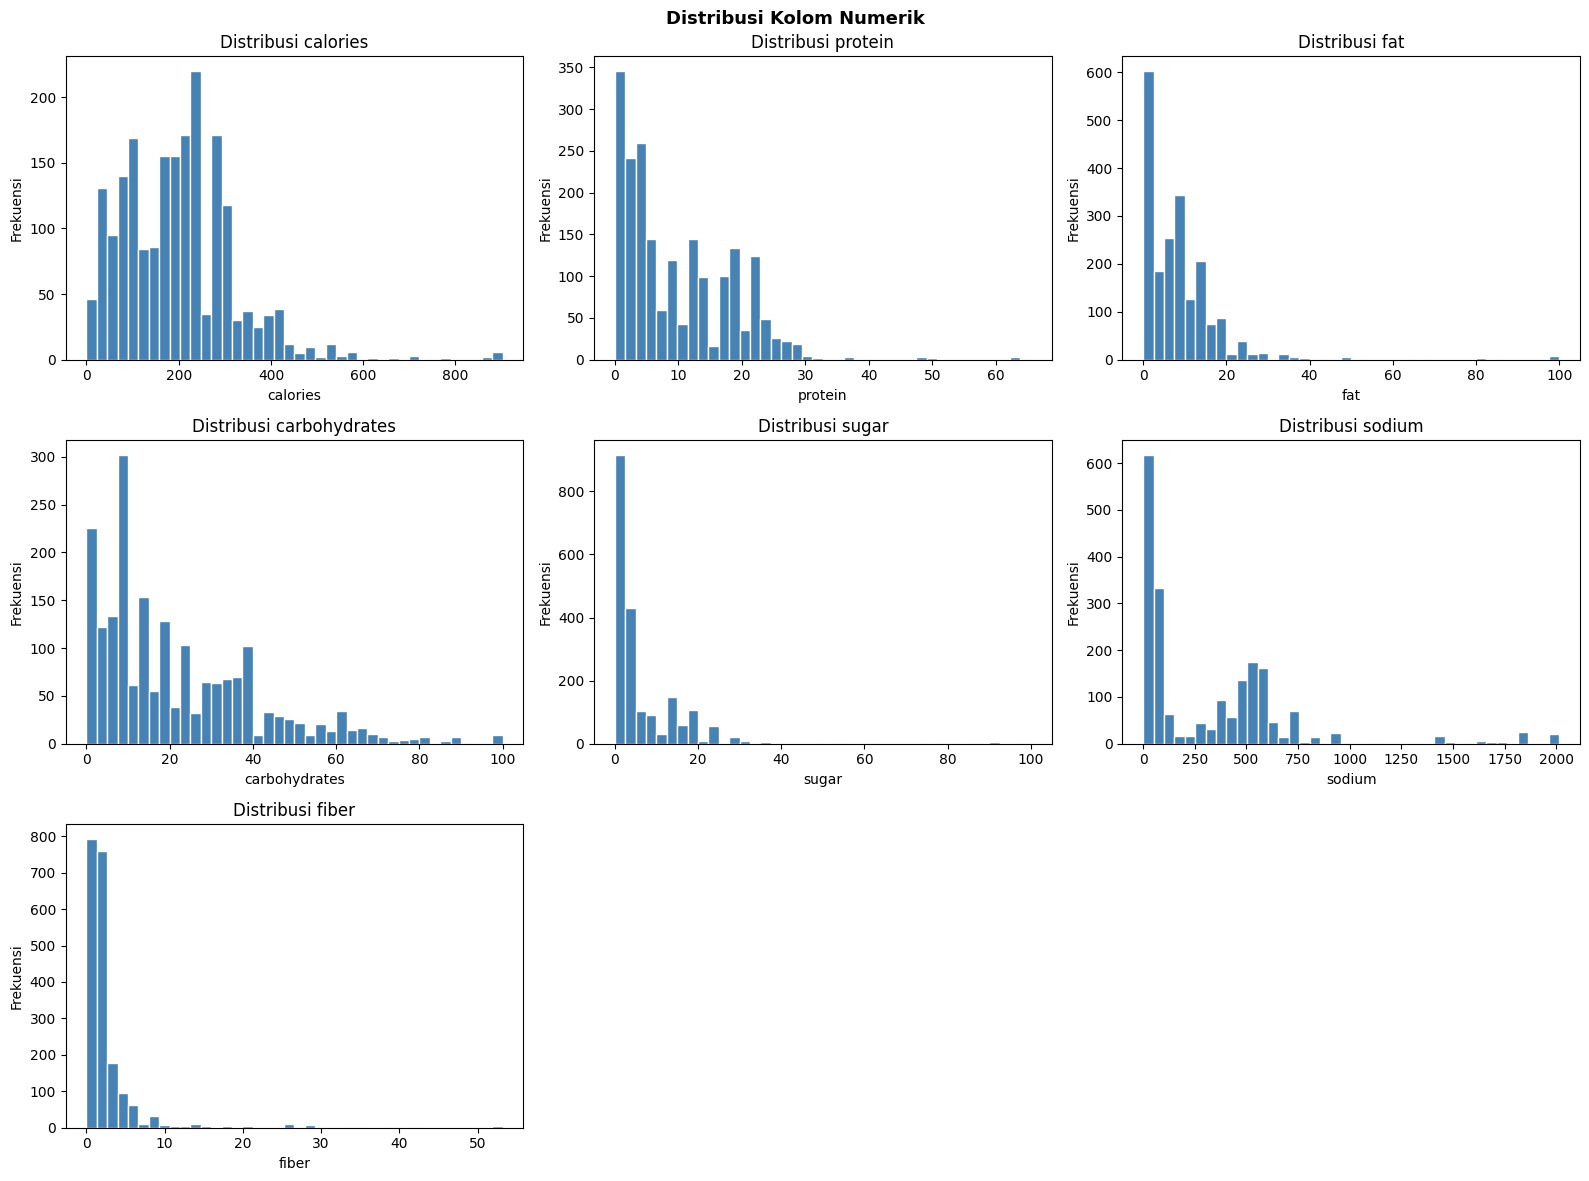

In [ ]:
#  DISTRIBUSI SETIAP KOLOM NUMERIK
num_cols = ['calories', 'protein', 'fat', 'carbohydrates', 'sugar', 'sodium', 'fiber']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Kolom Numerik',  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

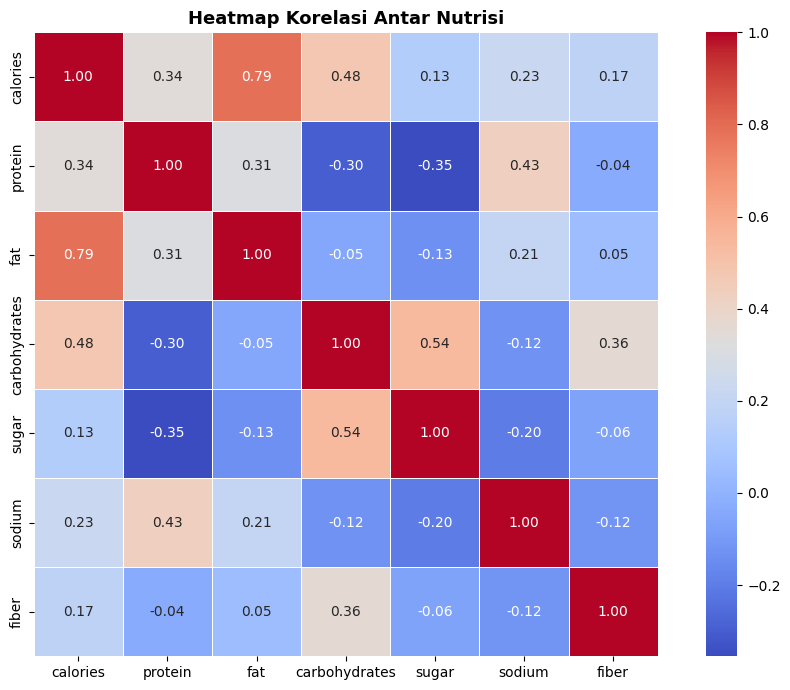

In [ ]:
# HEATMAP KORELASI
plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Nutrisi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

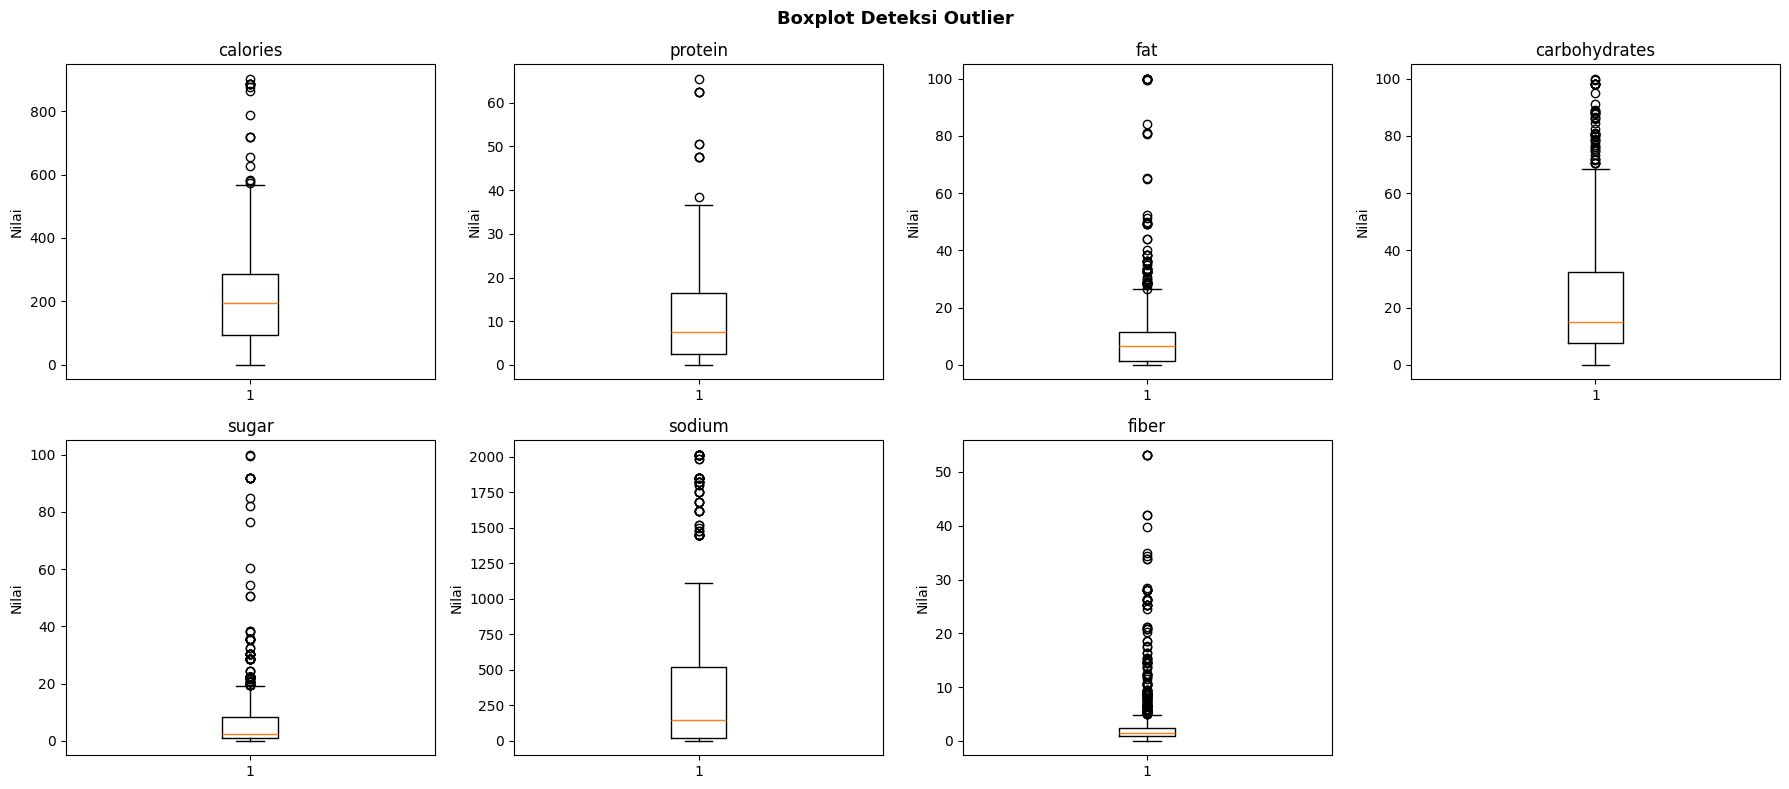

In [ ]:
# BOXPLOT DETEKSI OUTLIER
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Nilai')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Deteksi Outlier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

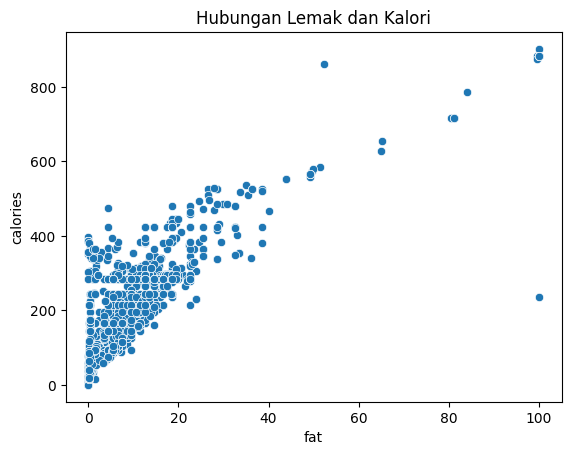

In [ ]:
# HUBUNGAN LEMAK VS KALORI
plt.figure()
sns.scatterplot(x='fat', y='calories', data=df)
plt.title("Hubungan Lemak dan Kalori")
plt.show()

# **VISUALIZATION & EXPLANATORY ANALYSIS**

## PERTANYAAN 1: Makanan mana yang menyediakan jumlah kalori, protein, lemak, dan karbohidrat tertinggi?

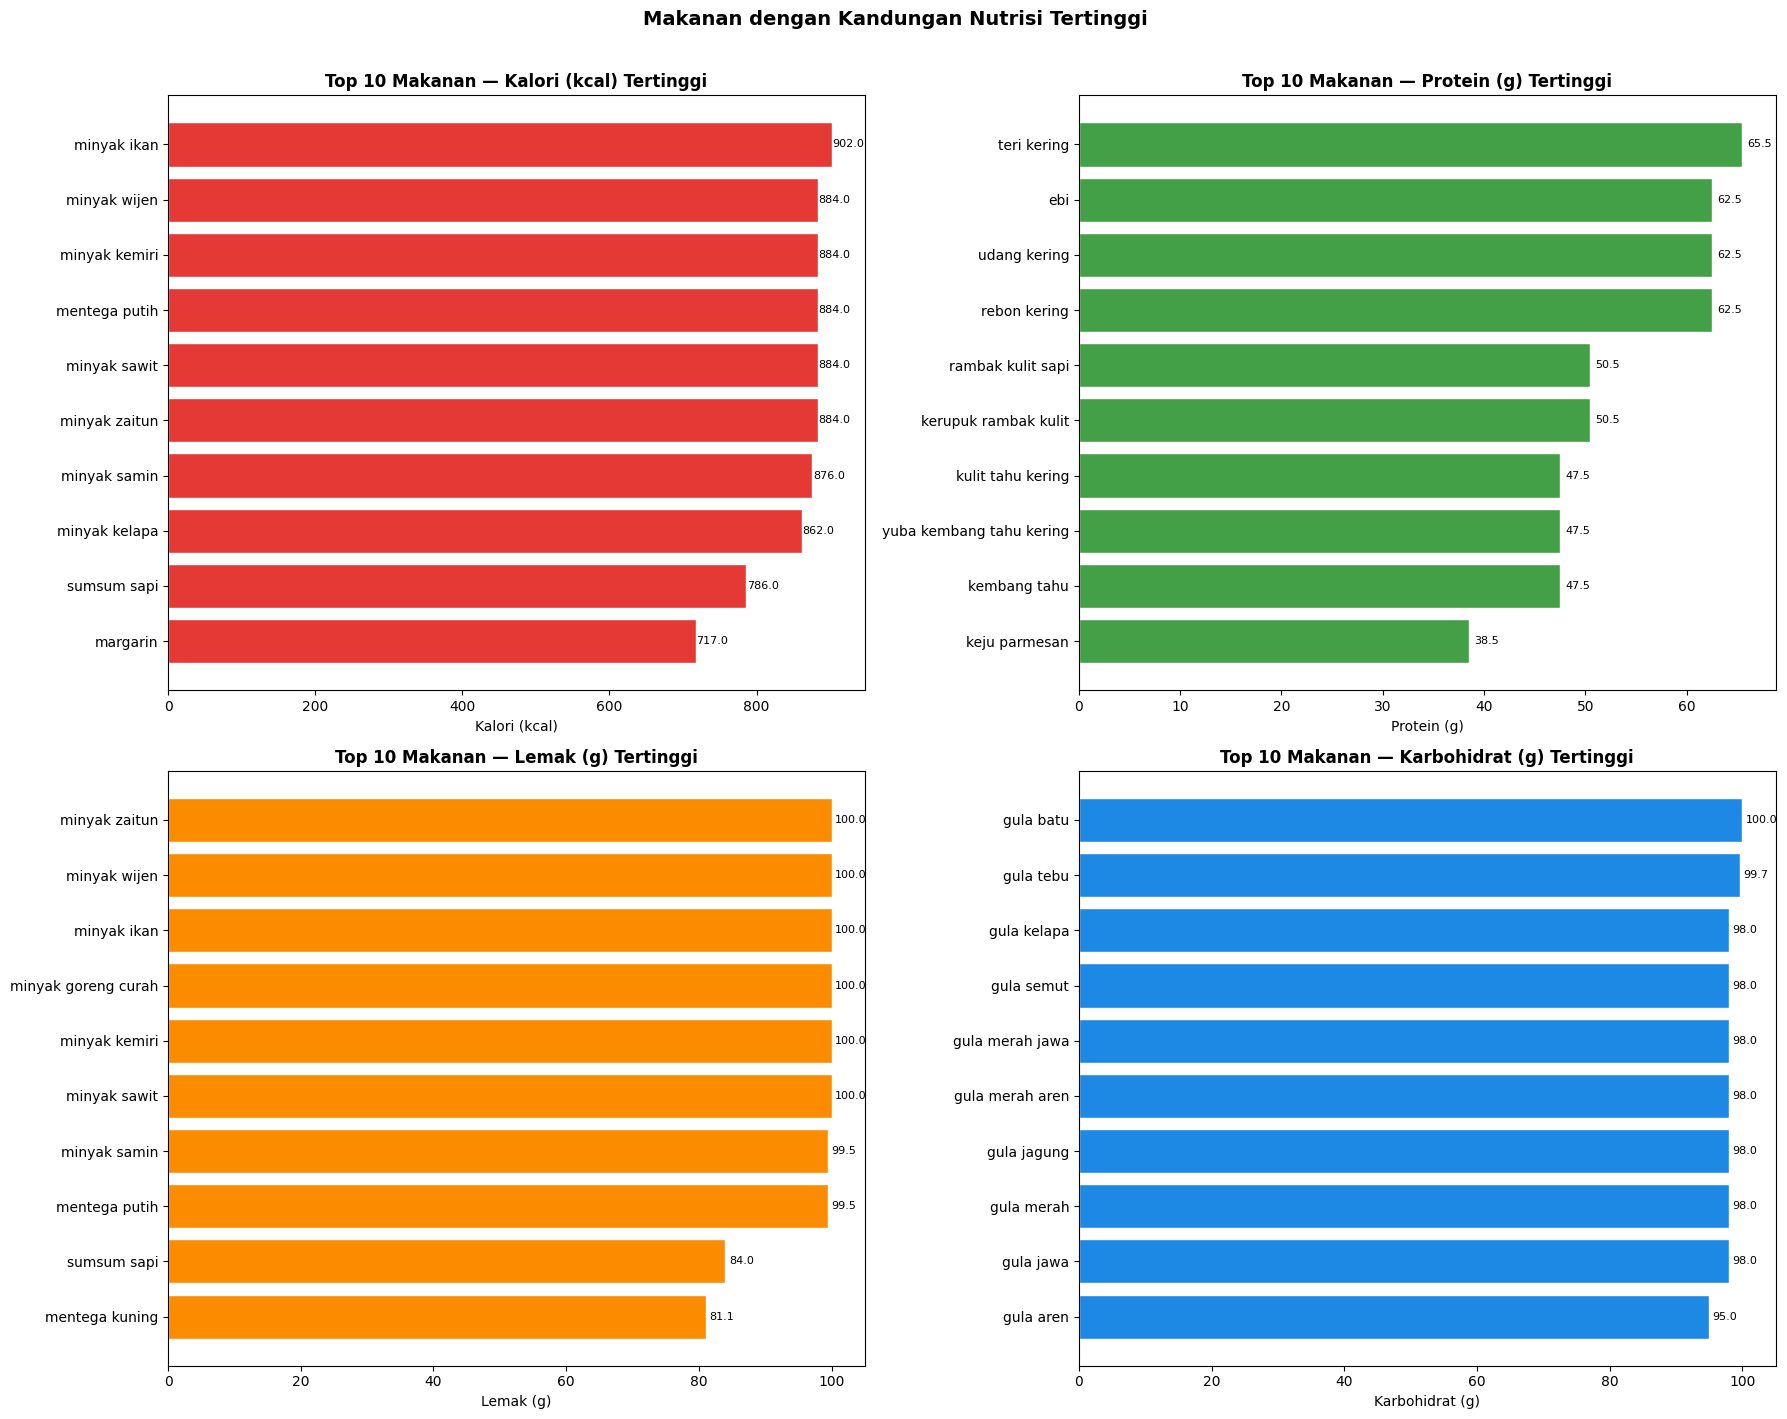

In [ ]:
metrics = ['calories', 'protein', 'fat', 'carbohydrates']
colors  = ['#E53935', '#43A047', '#FB8C00', '#1E88E5']
titles  = ['Kalori (kcal)', 'Protein (g)', 'Lemak (g)', 'Karbohidrat (g)']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (col, color, title) in enumerate(zip(metrics, colors, titles)):
    top10 = df.nlargest(10, col)[['food_name', col]].sort_values(col)
    axes[i].barh(top10['food_name'], top10[col], color=color, edgecolor='white')
    axes[i].set_title(f'Top 10 Makanan — {title} Tertinggi', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(title)
    for j, (val, name) in enumerate(zip(top10[col], top10['food_name'])):
        axes[i].text(val + 0.5, j, f'{val:.1f}', va='center', fontsize=8)

plt.suptitle('Makanan dengan Kandungan Nutrisi Tertinggi',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Insight:
1. Kalori Tertinggi Didominasi oleh Produk Minyak dan Lemak

Pada grafik kalori, makanan dengan kandungan energi tertinggi adalah:

- minyak ikan (902 kcal)
- minyak wijen, minyak kemiri, mentega putih, minyak sawit, minyak zaitun (884 kcal)
- minyak samin (876 kcal)

Produk berbasis minyak memiliki kalori sangat tinggi karena sebagian besar komposisinya adalah lemak. Ini menunjukkan bahwa makanan berminyak merupakan sumber energi paling padat.

2. Protein Tertinggi Didominasi oleh Produk Laut Kering
Pada grafik protein, makanan dengan protein tertinggi adalah:

- teri kering (65.5 g)
- ebi, udang kering, rebon kering (62.5 g)

Produk laut kering memiliki kandungan protein sangat tinggi karena kadar airnya rendah sehingga nutrisi menjadi lebih terkonsentrasi.
Bahan pangan hewani laut merupakan sumber protein utama dibanding bahan nabati.

3. Lemak Tertinggi Hampir Seluruhnya Berasal dari Minyak

Pada grafik lemak, hampir semua posisi teratas (100g lemak) ditempati oleh:

- minyak zaitun, minyak wijen, minyak ikan, minyak goreng curah, minyak kemiri, minyak sawit

Minyak murni hampir sepenuhnya tersusun atas lemak.
Hal ini sejalan dengan hasil grafik kalori, karena makanan tinggi lemak otomatis tinggi kalori.

4. Karbohidrat Tertinggi Didominasi oleh Jenis Gula

Pada grafik karbohidrat, posisi teratas ditempati oleh:

- gula batu (100 g)
- gula tebu (99.7 g)
- gula kelapa, gula merah, gula jagung, gula jawa (98 g)
- gula aren (95 g).

Produk gula hampir sepenuhnya terdiri dari karbohidrat sederhana.
Kandungan karbohidrat sangat tinggi menunjukkan gula merupakan sumber energi cepat.


## PERTANYAAN 2: Bagaimana rasio umum antara protein, lemak, dan karbohidrat pada makanan

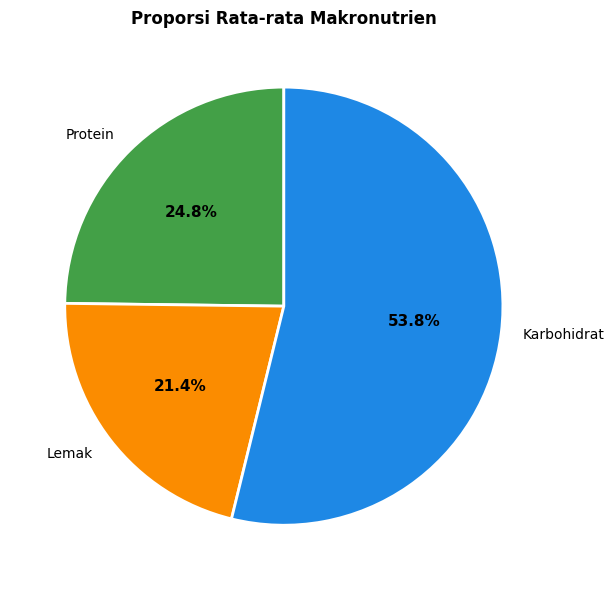

In [ ]:
avg_protein = df['protein'].mean()
avg_fat     = df['fat'].mean()
avg_carbs   = df['carbohydrates'].mean()

labels  = ['Protein', 'Lemak', 'Karbohidrat']
values  = [avg_protein, avg_fat, avg_carbs]
colors  = ['#43A047', '#FB8C00', '#1E88E5']

plt.figure(figsize=(7, 6))

wedges, texts, autotexts = plt.pie(
    values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')

plt.title('Proporsi Rata-rata Makronutrien', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight:
Berdasarkan visualisasi Proporsi Rata-rata Makronutrien, diperoleh komposisi rata-rata:

Karbohidrat: 53.8%, Protein: 24.8%, dan Lemak 21,4%

1. Karbohidrat Menjadi Makronutrien Dominan

    - Karbohidrat memiliki proporsi terbesar, yaitu lebih dari setengah total kandungan makronutrien.

    - Sebagian besar makanan dalam dataset cenderung berbasis sumber karbohidrat.
    - Hal ini mencerminkan pola konsumsi umum masyarakat yang menjadikan nasi, gula, tepung, dan bahan berpati sebagai sumber energi utama.


2. Protein Memiliki Proporsi Sedang

    - Protein menyumbang sekitar seperempat dari total makronutrien.

    - Kandungan protein cukup seimbang namun masih berada di bawah karbohidrat.
    - Ini menunjukkan bahwa makanan tinggi protein ada, tetapi tidak mendominasi keseluruhan dataset.

3. Lemak Memiliki Proporsi Paling Rendah

    - Lemak memiliki proporsi terkecil dibanding dua makronutrien lainnya.

    - Walaupun beberapa makanan memiliki kandungan lemak sangat tinggi (seperti minyak), secara rata-rata kontribusi lemak pada seluruh dataset tetap lebih rendah.
    - Hal ini terjadi karena tidak semua makanan mengandung lemak tinggi.


## PERTANYAAN 3: Berapa persentase makanan yang memiliki kalori di bawah 100 dan di atas 500?

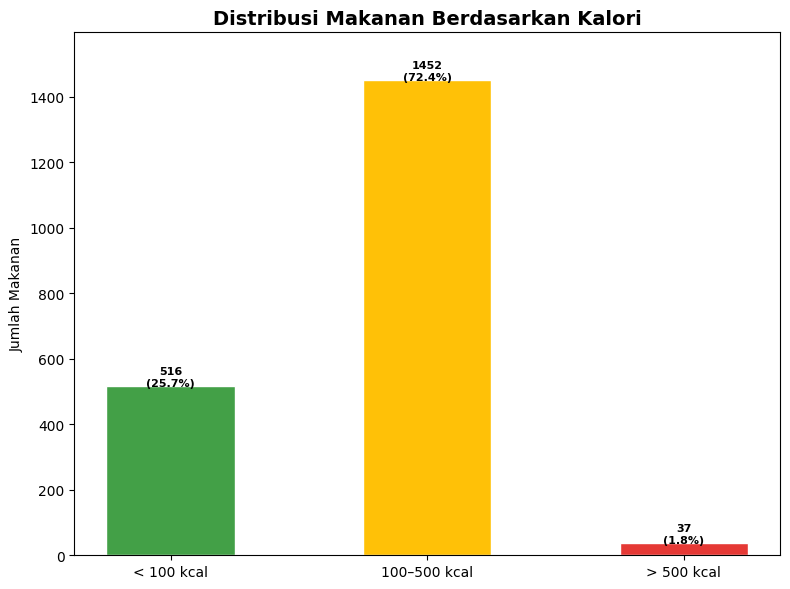

In [ ]:
low_cal  = (df['calories'] < 100).sum()
high_cal = (df['calories'] > 500).sum()
mid_cal  = len(df) - low_cal - high_cal
total    = len(df)

labels = ['< 100 kcal', '100–500 kcal', '> 500 kcal']
sizes  = [low_cal, mid_cal, high_cal]
colors = ['#43A047', '#FFC107', '#E53935']

plt.figure(figsize=(8, 6))

bars = plt.bar(labels, sizes, color=colors, edgecolor='white', width=0.5)

plt.title('Distribusi Makanan Berdasarkan Kalori',
          fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Makanan')
plt.ylim(0, max(sizes) * 1.1)

for bar, val in zip(bars, sizes):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val}\n({val/total*100:.1f}%)',
             ha='center',
             fontweight='bold',
             fontsize=8)

plt.tight_layout()
plt.show()

### Insight:
- Mayoritas data didominasi oleh makanan dengan kandungan kalori sedang (100-500 kcal), yaitu sebanyak 1452 makanan (72,4%).

- Makanan rendah kalori (<100 kcal) masih cukup banyak ditemukan dalam dataset dengan total 516 makanan (25,7%).

- Makanan sangat tinggi kalori (>500 kcal) jumlahnya sangat sedikit, hanya 37 makanan dari seluruh data (1,8%).



## PERTANYAAN 4: Apakah makanan tinggi kalori cenderung juga tinggi lemak?

/tmp/ipykernel_2057/2245471225.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(fat_groups,


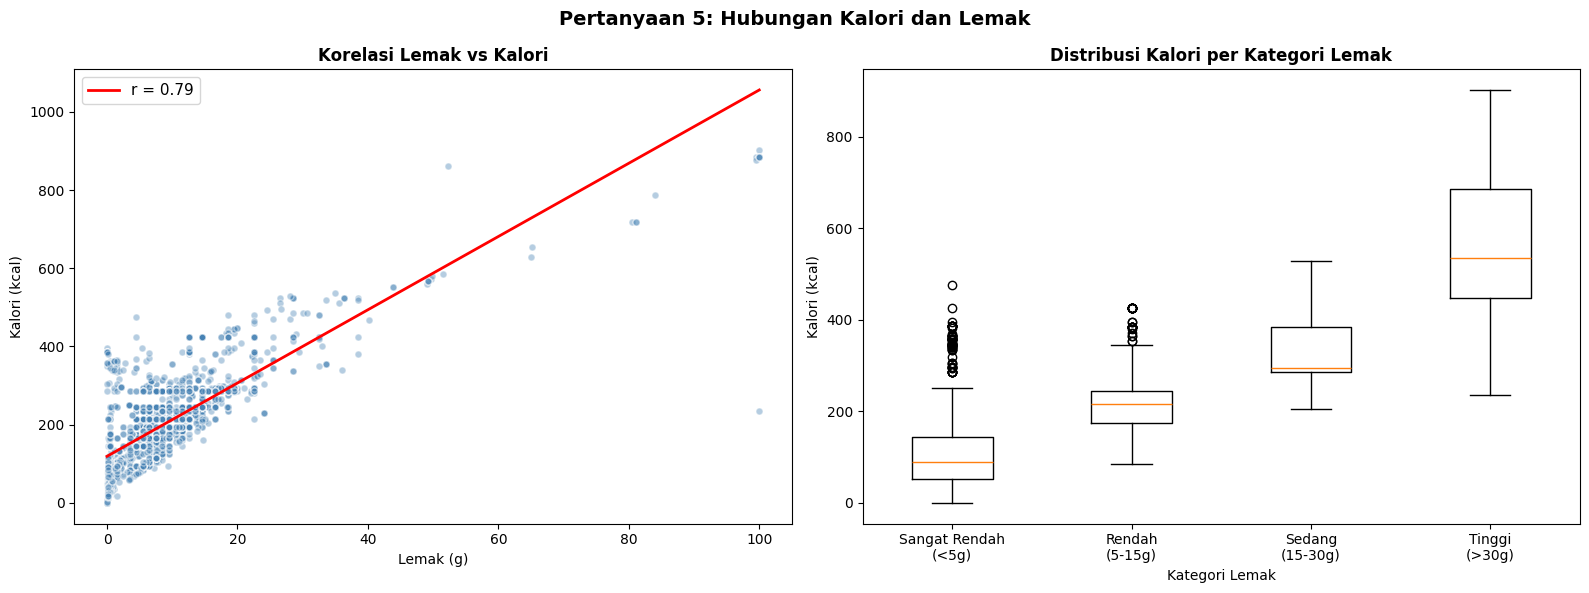

In [ ]:
corr_val = df['fat'].corr(df['calories'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(df['fat'], df['calories'], alpha=0.4,
                color='steelblue', edgecolors='white', s=25)
m, b   = np.polyfit(df['fat'], df['calories'], 1)
x_line = np.linspace(df['fat'].min(), df['fat'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='red',
             linewidth=2, label=f'r = {corr_val:.2f}')
axes[0].set_title('Korelasi Lemak vs Kalori', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lemak (g)')
axes[0].set_ylabel('Kalori (kcal)')
axes[0].legend(fontsize=11)

# Boxplot kalori per kategori lemak
df['fat_category'] = pd.cut(df['fat'],
    bins=[-1, 5, 15, 30, float('inf')],
    labels=['Sangat Rendah\n(<5g)', 'Rendah\n(5-15g)',
            'Sedang\n(15-30g)', 'Tinggi\n(>30g)'])
fat_groups = [df[df['fat_category'] == cat]['calories'].dropna()
              for cat in df['fat_category'].cat.categories]
axes[1].boxplot(fat_groups,
                labels=['Sangat Rendah\n(<5g)', 'Rendah\n(5-15g)',
                        'Sedang\n(15-30g)', 'Tinggi\n(>30g)'])
axes[1].set_title('Distribusi Kalori per Kategori Lemak', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kategori Lemak')
axes[1].set_ylabel('Kalori (kcal)')

plt.suptitle('Pertanyaan 4: Hubungan Kalori dan Lemak',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight:
Berdasarkan visualisasi scatter plot dan boxplot, terlihat adanya hubungan positif antara kandungan lemak dan jumlah kalori pada makanan.

- Nilai korelasi antara lemak dan kalori adalah r = 0.79, yang menunjukkan hubungan positif cukup kuat.

- Semakin tinggi kandungan lemak suatu makanan, semakin tinggi pula kalorinya.

- Pada scatter plot, titik data membentuk pola naik dari kiri bawah ke kanan atas, menandakan hubungan searah antara lemak dan kalori.

Distribusi kalori juga meningkat pada setiap kategori lemak:


*   Makanan dengan lemak sangat rendah (<5g) memiliki median kalori paling rendah.
*   Kategori lemak rendah (5-15g) menunjukkan peningkatan jumlah kalori.
*   Kategori lemak sedang (15-30g) memiliki distribusi kalori yang lebih tinggi lagi.
*   Makanan dengan lemak tinggi (>30g) memiliki median dan rentang kalori tertinggi dibanding kategori lainnya.

=== RATA-RATA KALORI ===
High Sodium : 230.39
Low Sodium  : 167.71

=== HASIL T-TEST ===
T-Statistic : 11.9048
P-Value     : 0.0

Terdapat perbedaan signifikan.
Makanan high sodium cenderung memiliki kalori lebih tinggi.


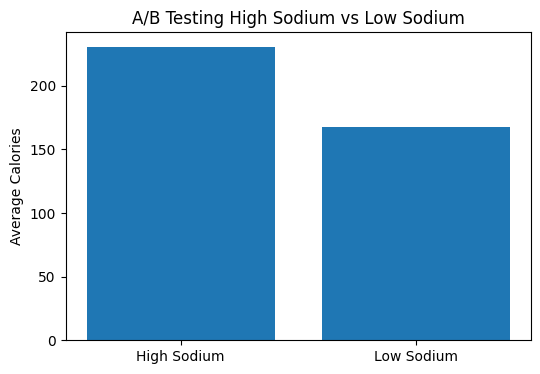

In [ ]:
# =========================================
# A/B TESTING
# HIGH SODIUM vs LOW SODIUM
# =========================================

import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# Feature Engineering
df['is_high_sodium'] = (
    df['sodium'] > df['sodium'].median()
).astype(int)

# Grouping
group_A = df[df['is_high_sodium'] == 1]['calories']
group_B = df[df['is_high_sodium'] == 0]['calories']

# Mean
mean_A = np.mean(group_A)
mean_B = np.mean(group_B)

print("=== RATA-RATA KALORI ===")
print("High Sodium :", round(mean_A, 2))
print("Low Sodium  :", round(mean_B, 2))

# T-Test
t_stat, p_value = ttest_ind(group_A, group_B)

print("\n=== HASIL T-TEST ===")
print("T-Statistic :", round(t_stat, 4))
print("P-Value     :", round(p_value, 6))

# Interpretasi
alpha = 0.05

if p_value < alpha:
    print("\nTerdapat perbedaan signifikan.")

    if mean_A > mean_B:
        print("Makanan high sodium cenderung memiliki kalori lebih tinggi.")
    else:
        print("Makanan high sodium cenderung memiliki kalori lebih rendah.")
else:
    print("\nTidak terdapat perbedaan signifikan.")

# Visualisasi
labels = ['High Sodium', 'Low Sodium']
means = [mean_A, mean_B]

plt.figure(figsize=(6,4))
plt.bar(labels, means)
plt.ylabel('Average Calories')
plt.title('A/B Testing High Sodium vs Low Sodium')
plt.show()

=== RATA-RATA GULA ===
High Carb : 10.7
Low Carb  : 2.26

=== HASIL T-TEST ===
T-Statistic : 20.9064
P-Value     : 0.0

Terdapat perbedaan signifikan.
Makanan high carb cenderung memiliki gula lebih tinggi.


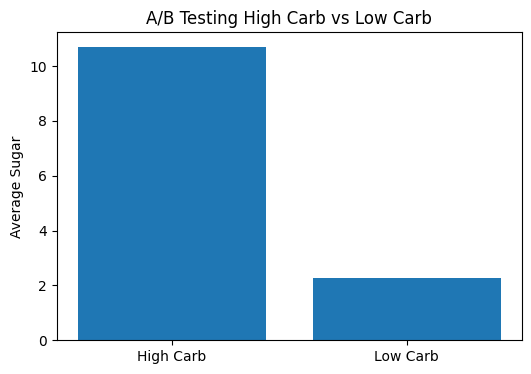

In [ ]:
# =========================================
# A/B TESTING
# HIGH CARB vs LOW CARB
# =========================================

import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# Feature Engineering
df['is_high_carb'] = (
    df['carbohydrates'] > df['carbohydrates'].median()
).astype(int)

# Grouping
group_A = df[df['is_high_carb'] == 1]['sugar']
group_B = df[df['is_high_carb'] == 0]['sugar']

# Mean
mean_A = np.mean(group_A)
mean_B = np.mean(group_B)

print("=== RATA-RATA GULA ===")
print("High Carb :", round(mean_A, 2))
print("Low Carb  :", round(mean_B, 2))

# T-Test
t_stat, p_value = ttest_ind(group_A, group_B)

print("\n=== HASIL T-TEST ===")
print("T-Statistic :", round(t_stat, 4))
print("P-Value     :", round(p_value, 6))

# Interpretasi
alpha = 0.05

if p_value < alpha:
    print("\nTerdapat perbedaan signifikan.")

    if mean_A > mean_B:
        print("Makanan high carb cenderung memiliki gula lebih tinggi.")
    else:
        print("Makanan high carb cenderung memiliki gula lebih rendah.")
else:
    print("\nTidak terdapat perbedaan signifikan.")

# Visualisasi
labels = ['High Carb', 'Low Carb']
means = [mean_A, mean_B]

plt.figure(figsize=(6,4))
plt.bar(labels, means)
plt.ylabel('Average Sugar')
plt.title('A/B Testing High Carb vs Low Carb')
plt.show()

=== RATA-RATA PROTEIN ===
High Fat : 13.57
Low Fat  : 6.31

=== HASIL T-TEST ===
T-Statistic : 20.6159
P-Value     : 0.0

Terdapat perbedaan signifikan.
Makanan high fat cenderung memiliki protein lebih tinggi.


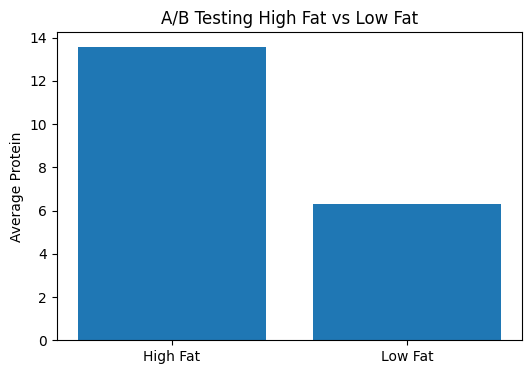

In [ ]:
# =========================================
# A/B TESTING
# HIGH FAT vs LOW FAT
# =========================================

# Feature Engineering
df['is_high_fat'] = (
    df['fat'] > df['fat'].median()
).astype(int)

# Grouping
group_A = df[df['is_high_fat'] == 1]['protein']
group_B = df[df['is_high_fat'] == 0]['protein']

# Mean
mean_A = np.mean(group_A)
mean_B = np.mean(group_B)

print("=== RATA-RATA PROTEIN ===")
print("High Fat :", round(mean_A, 2))
print("Low Fat  :", round(mean_B, 2))

# T-Test
t_stat, p_value = ttest_ind(group_A, group_B)

print("\n=== HASIL T-TEST ===")
print("T-Statistic :", round(t_stat, 4))
print("P-Value     :", round(p_value, 6))

# Interpretasi
alpha = 0.05

if p_value < alpha:
    print("\nTerdapat perbedaan signifikan.")

    if mean_A > mean_B:
        print("Makanan high fat cenderung memiliki protein lebih tinggi.")
    else:
        print("Makanan high fat cenderung memiliki protein lebih rendah.")
else:
    print("\nTidak terdapat perbedaan signifikan.")

# Visualisasi
labels = ['High Fat', 'Low Fat']
means = [mean_A, mean_B]

plt.figure(figsize=(6,4))
plt.bar(labels, means)
plt.ylabel('Average Protein')
plt.title('A/B Testing High Fat vs Low Fat')
plt.show()